In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# width
pd.set_option('display.width', 1000)

In [18]:
DATASET = "DUDE"
RESULTS_BASE = "/home/amartinelli/VRD-UQA/results_1746593/DUDE/LLM"  # directory containing results_w1/, results_w2/, etc.

# MODELS = [
#     'Phi4', 'Molmo', 'Ovis', 'Llama', 'Llava34', 'Gemma27',
#     'Qwen', 'QwenOllama', 'InternVL3', 'InternVL378', 'GPT-4.1', 'O3',
# ]
MODELS = ['Qwen']
# MODEL_LABELS = [
#     'Phi4', 'Molmo', 'Ovis', 'Llama', 'Llava34', 'Gemma27',
#     'Qwen', 'Qwen72', 'InternVL', 'InternVL78', 'GPT-4.1-mini', 'O3',
# ]
MODEL_LABELS = ['Qwen']
# MOLMO_IDX = MODELS.index('Molmo')

W_COLORS          = ['#3F9F19', '#FFB60A', '#703AA6']
COMPLEXITY_COLORS = ['#8E3B46', '#F3712B', '#0070E0']
CONDITION_COLORS  = ['#D02536', '#3F88C5', '#F49D37', '#06896D']

QUR_PLOT_DIR = f"{RESULTS_BASE}/plots/QUR"
UR_PLOT_DIR = f"{RESULTS_BASE}/plots/UR"

os.makedirs(QUR_PLOT_DIR, exist_ok=True)
os.makedirs(UR_PLOT_DIR,  exist_ok=True)

In [15]:
def load_metric(folder, metric_file, row, models=None):
    """Load a metric CSV and return the specified row as a numpy array.

    Zeros out Molmo for OCR folders (no OCR results available for that model).
    """
    if models is None:
        models = MODELS
    path = f"{RESULTS_BASE}/{folder}/results/{metric_file}.csv"
    df = pd.read_csv(path, index_col=0)
    if "ocr" in folder and "Molmo" in df.columns:
        df["Molmo"] = 0.0
    return df[models].loc[row].values


def bar_chart(data, group_labels, colors, ylabel, savepath,
              x_labels=None, figsize=(14, 6), molmo_idx=None):
    """Grouped bar chart across models.

    Args:
        data:         List of 1-D arrays, one per group.
        group_labels: Legend label for each group.
        colors:       Bar color for each group.
        ylabel:       Y-axis label.
        savepath:     PDF output path.
        x_labels:     X-tick labels (defaults to MODEL_LABELS).
        molmo_idx:    If set, this model only shows groups 0 and 2
                      (Explicit and None; OCR runs unavailable for Molmo).
    """
    if x_labels is None:
        x_labels = MODEL_LABELS
    n_groups = len(data)
    width = 0.2
    offsets = (np.arange(n_groups) - (n_groups - 1) / 2) * width

    fig, ax = plt.subplots(figsize=figsize, dpi=200)
    x = np.arange(len(x_labels))

    for g, (arr, label, color, offset) in enumerate(zip(data, group_labels, colors, offsets)):
        for i, val in enumerate(arr):
            if molmo_idx is not None and i == molmo_idx and g not in (0, 2):
                continue  # Molmo has no OCR results
            ax.bar(x[i] + offset, val, width, color=color,
                   label=label if i == 0 else None)

    ax.set_xlabel("VLLM", fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=16, rotation=25, ha="right")
    ax.tick_params(axis="y", labelsize=16)
    ax.legend(fontsize=16, loc="upper left")
    ax.grid(True, axis="y", linestyle="--", alpha=0.7)
    fig.tight_layout()
    fig.savefig(savepath)
    plt.show()


# AccD

In [22]:
# QUR across sliding-window sizes (W1=1 page, W2=2 pages, W3=3 pages)
folders = ["results_w1", "results_w2", "results_w3"]
data = [load_metric(f, "QUR", "QUR") for f in folders]

bar_chart(
    data,
    group_labels=["W1", "W2", "W3"],
    colors=W_COLORS,
    ylabel="$QUR$",
    savepath=f"{QUR_PLOT_DIR}/{DATASET}_QUR_Wcomparison.pdf",
)

FileNotFoundError: [Errno 2] No such file or directory: '/home/amartinelli/VRD-UQA/results_1746593/DUDE/LLM/results_w1/results/QUR.csv'

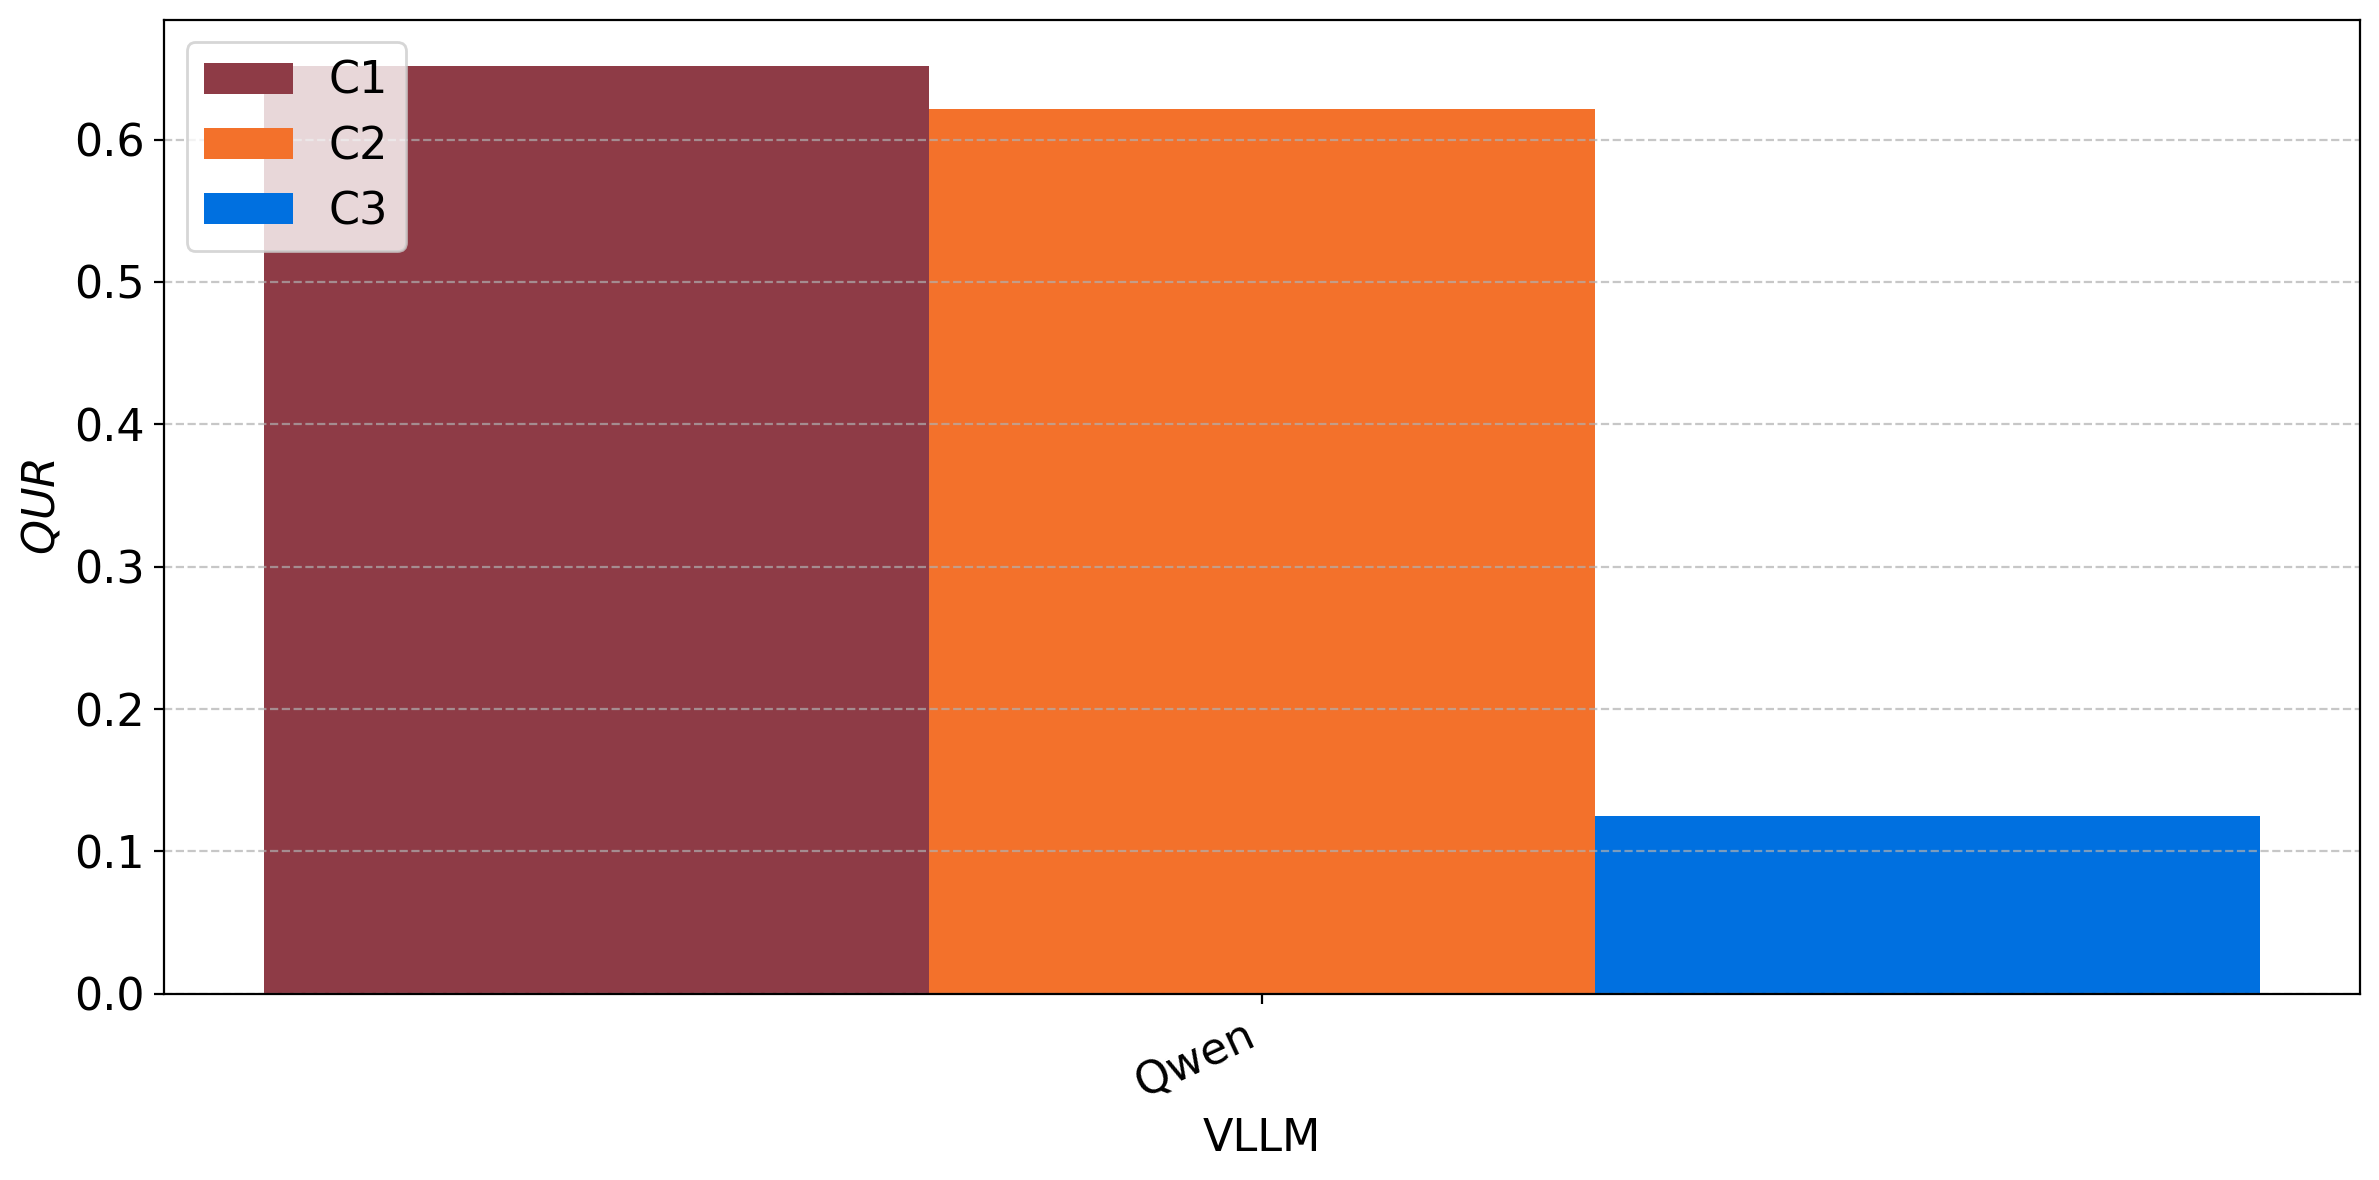

In [21]:
# QUR by corruption complexity for W1 (C1=easy, C2=medium, C3=hard)
data = [load_metric("results_w1_OCR", "QUR", key) for key in ["QUR_C1", "QUR_C2", "QUR_C3"]]

bar_chart(
    data,
    group_labels=["C1", "C2", "C3"],
    colors=COMPLEXITY_COLORS,
    ylabel="$QUR$",
    savepath=f"{QUR_PLOT_DIR}/{DATASET}_QUR_Ccomparison.pdf",
    figsize=(12, 6),
)

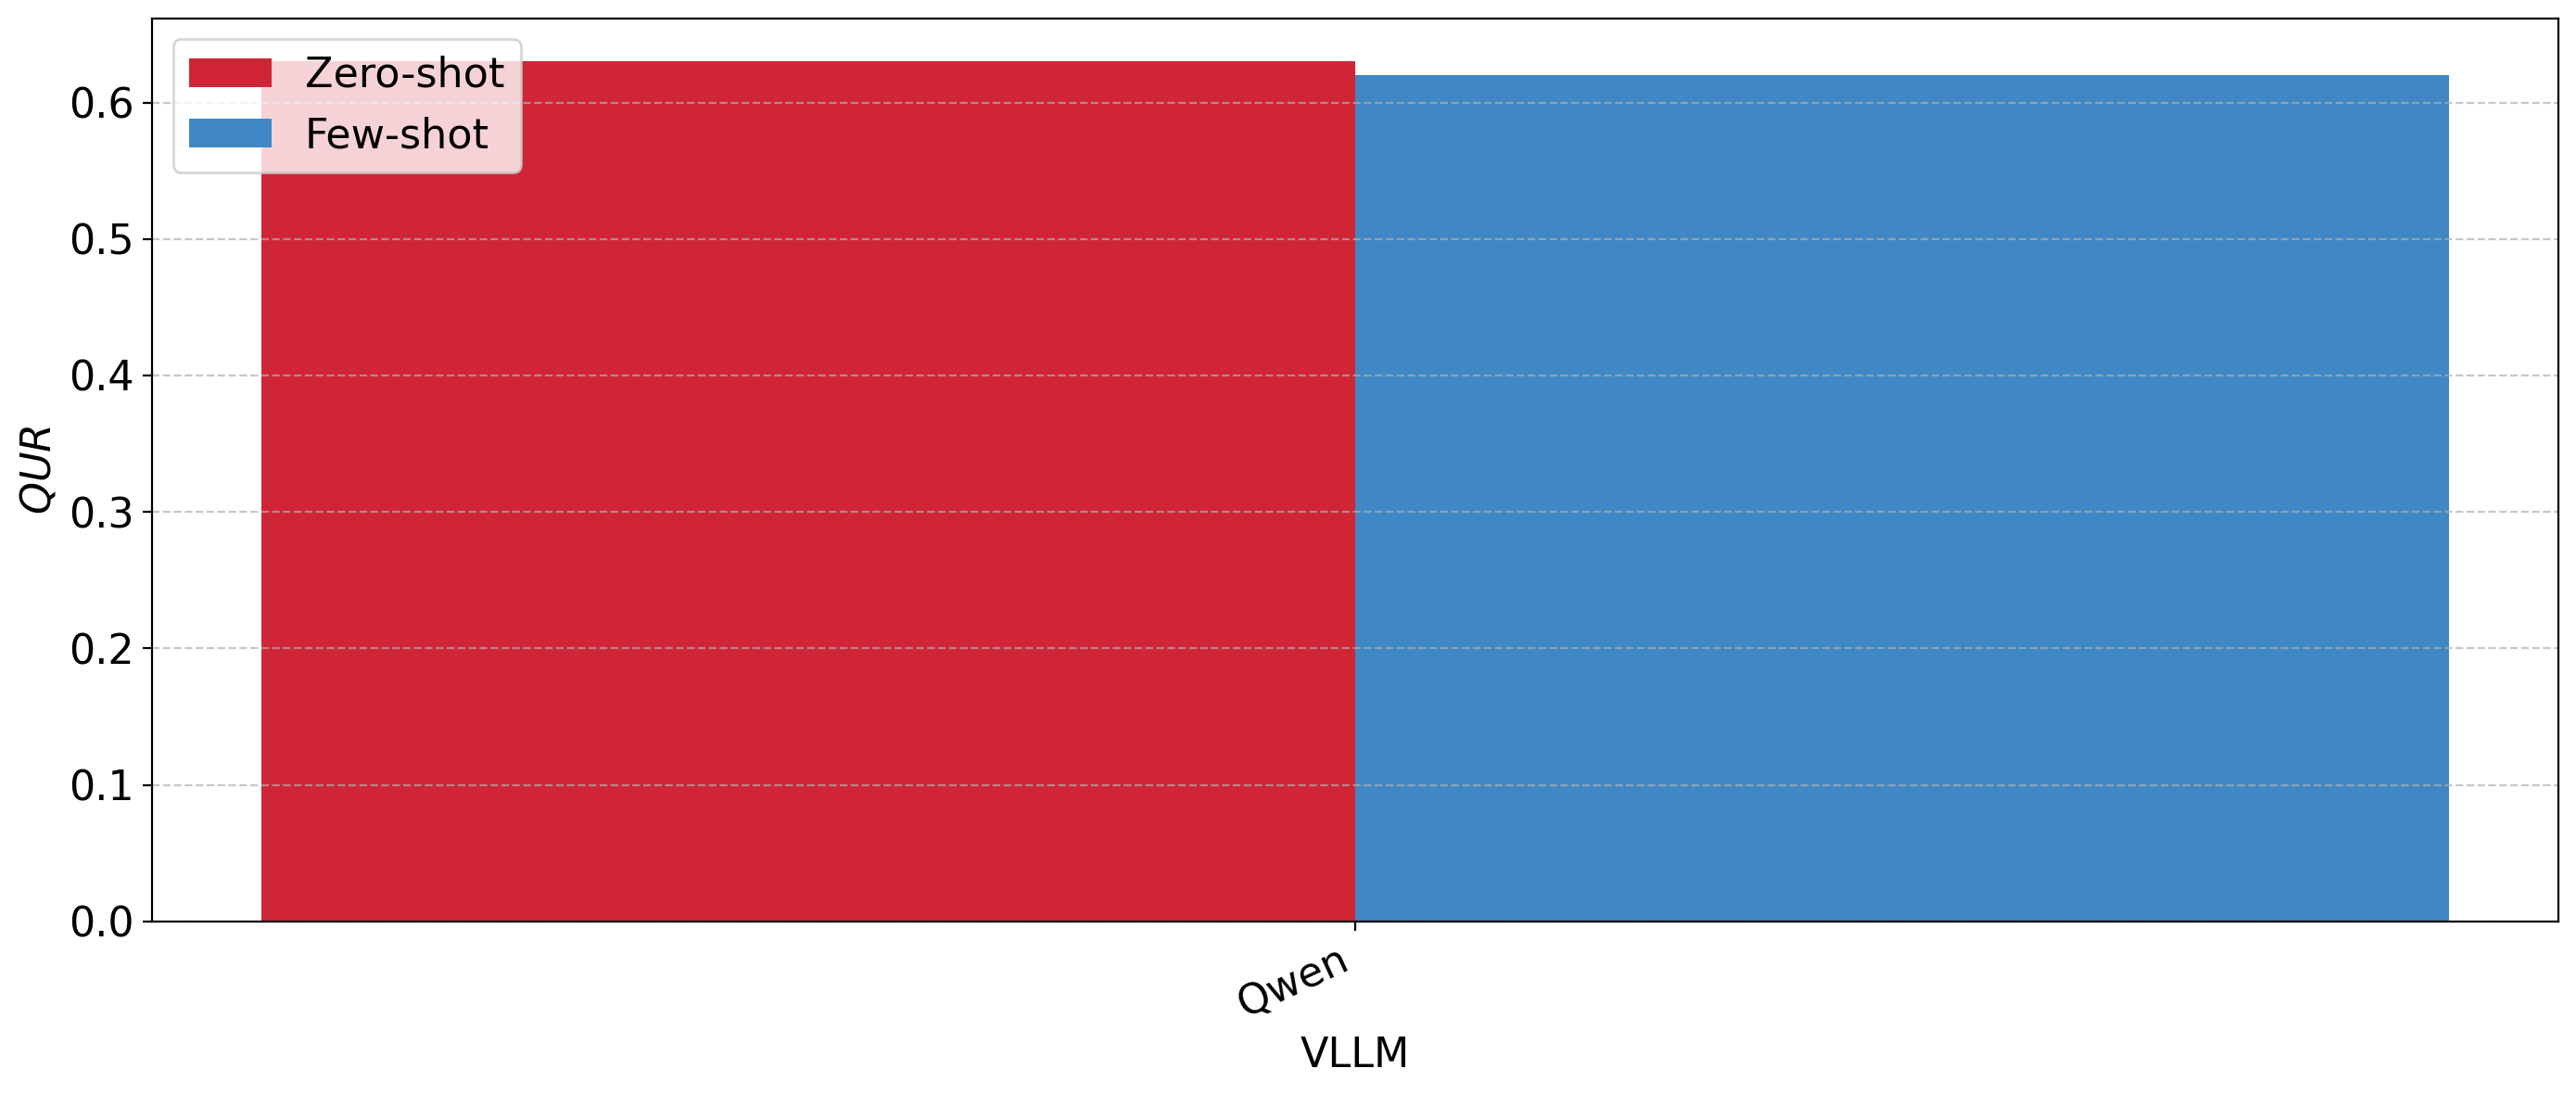

In [20]:
# QUR across inference conditions: unanswerability prompt (Explicit/None) × OCR injection
folders = ["results_w1_OCR", "results_w1_OCR_fewshot_mixed_2"]
data = [load_metric(f, "QUR", "QUR") for f in folders]

bar_chart(
    data,
    group_labels=["Zero-shot", "Few-shot"],
    colors=CONDITION_COLORS,
    ylabel="$QUR$",
    savepath=f"{QUR_PLOT_DIR}/{DATASET}_QUR_1parameter.pdf",
    # molmo_idx=MOLMO_IDX,
)

# AccP

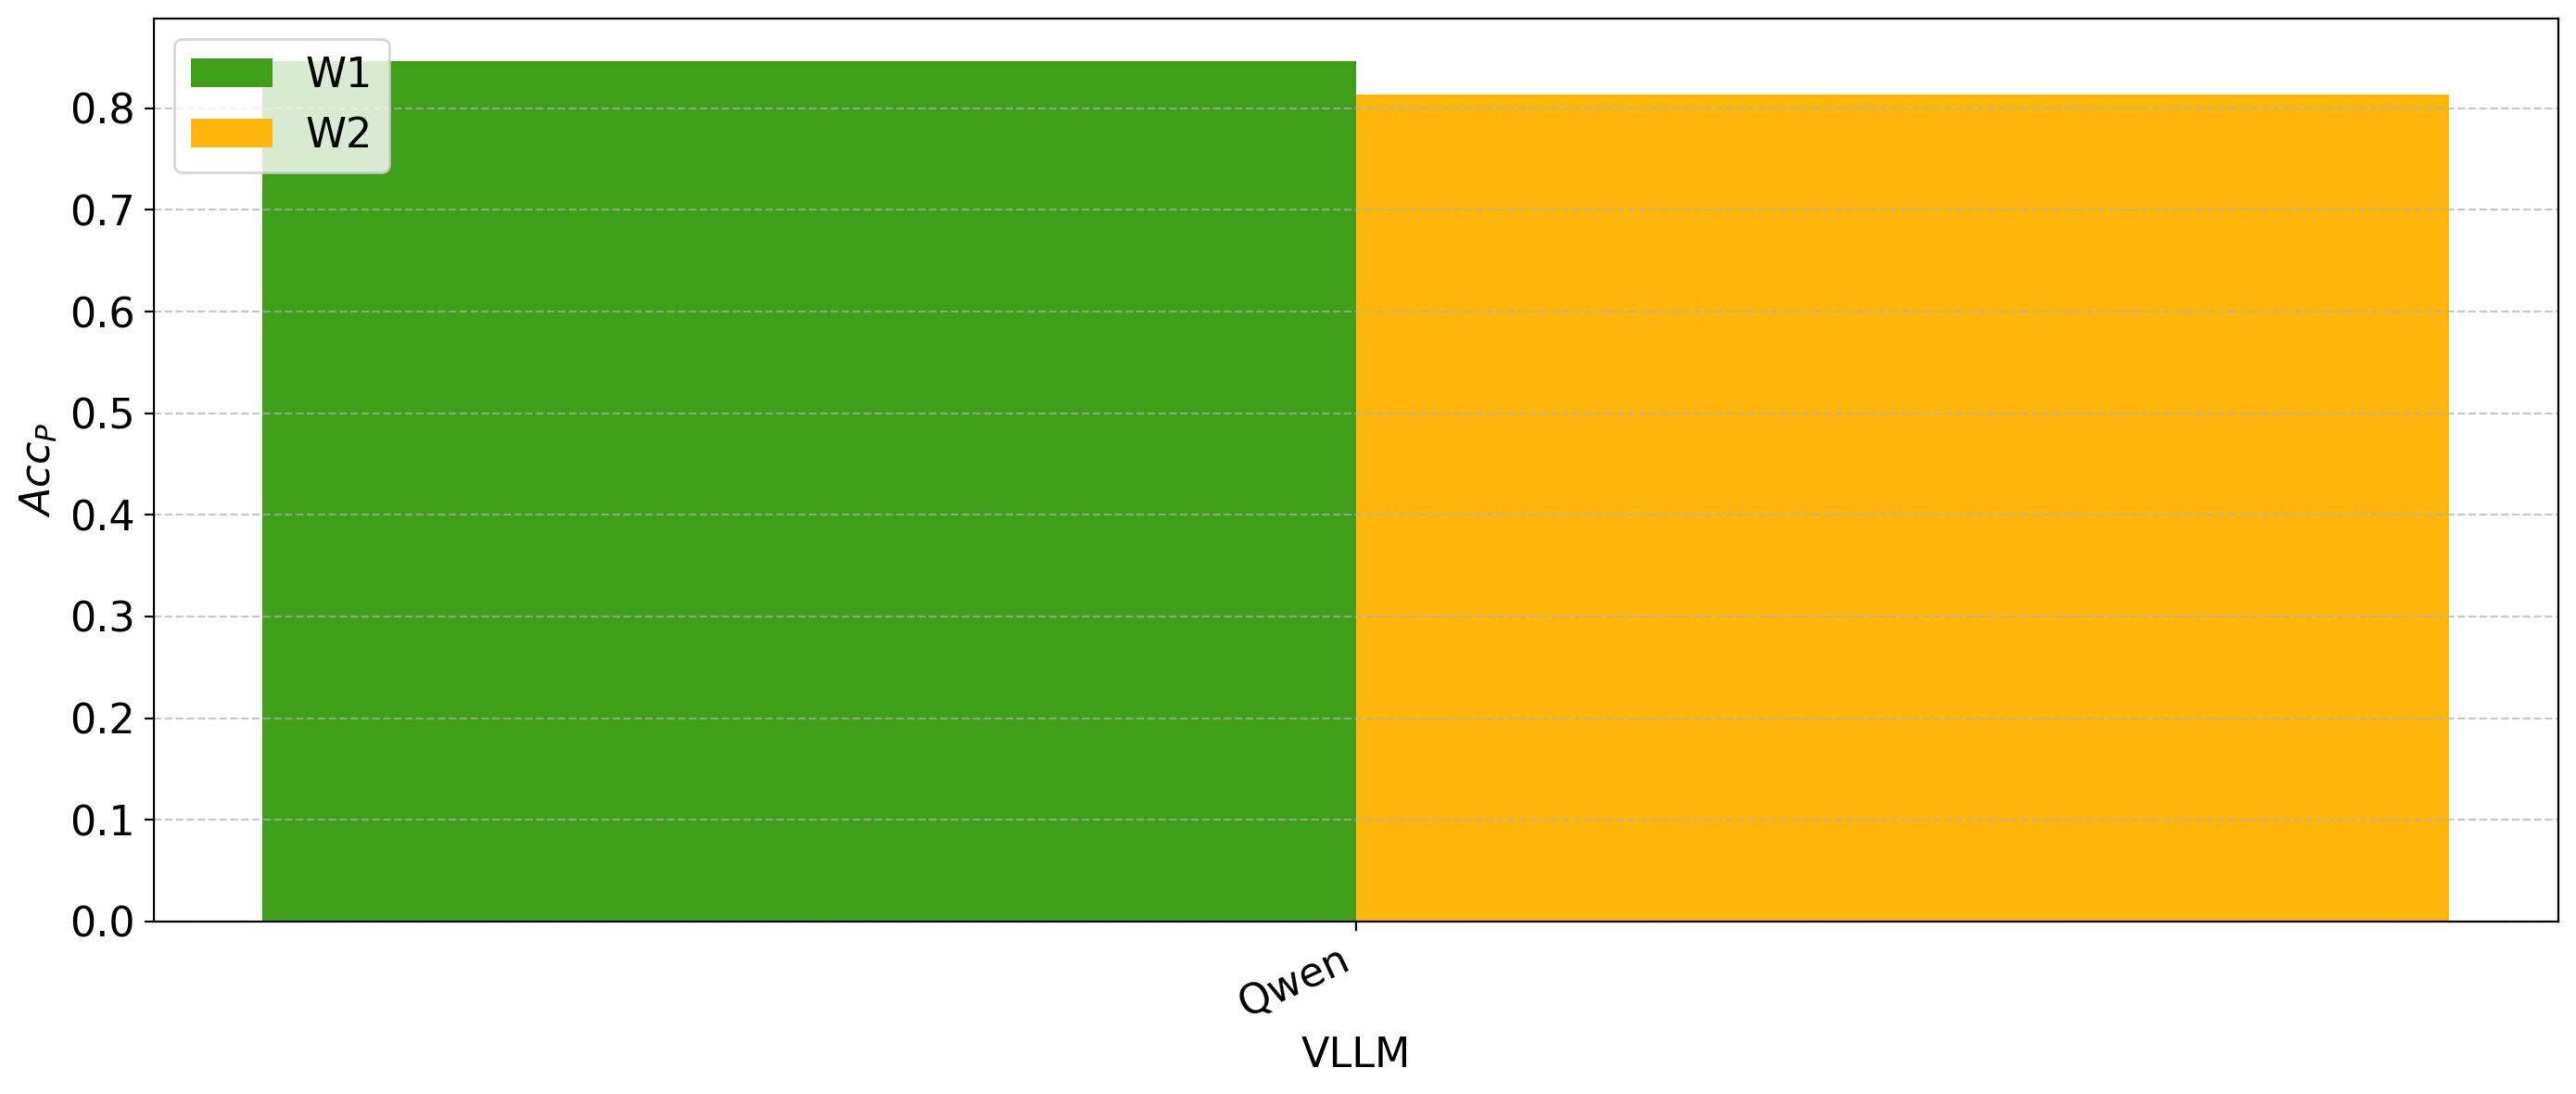

In [27]:
# AccP across sliding-window sizes (W1=1 page, W2=2 pages, W3=3 pages)
folders = ["results_w1_OCR", "results_w1_OCR_fewshot_mixed_2"]
data = [load_metric(f, "UR", "UR") for f in folders]

bar_chart(
    data,
    group_labels=["W1", "W2", "W3"],
    colors=W_COLORS,
    ylabel="$Acc_P$",
    savepath=f"{UR_PLOT_DIR}/{DATASET}_UR_Wcomparison.pdf",
)

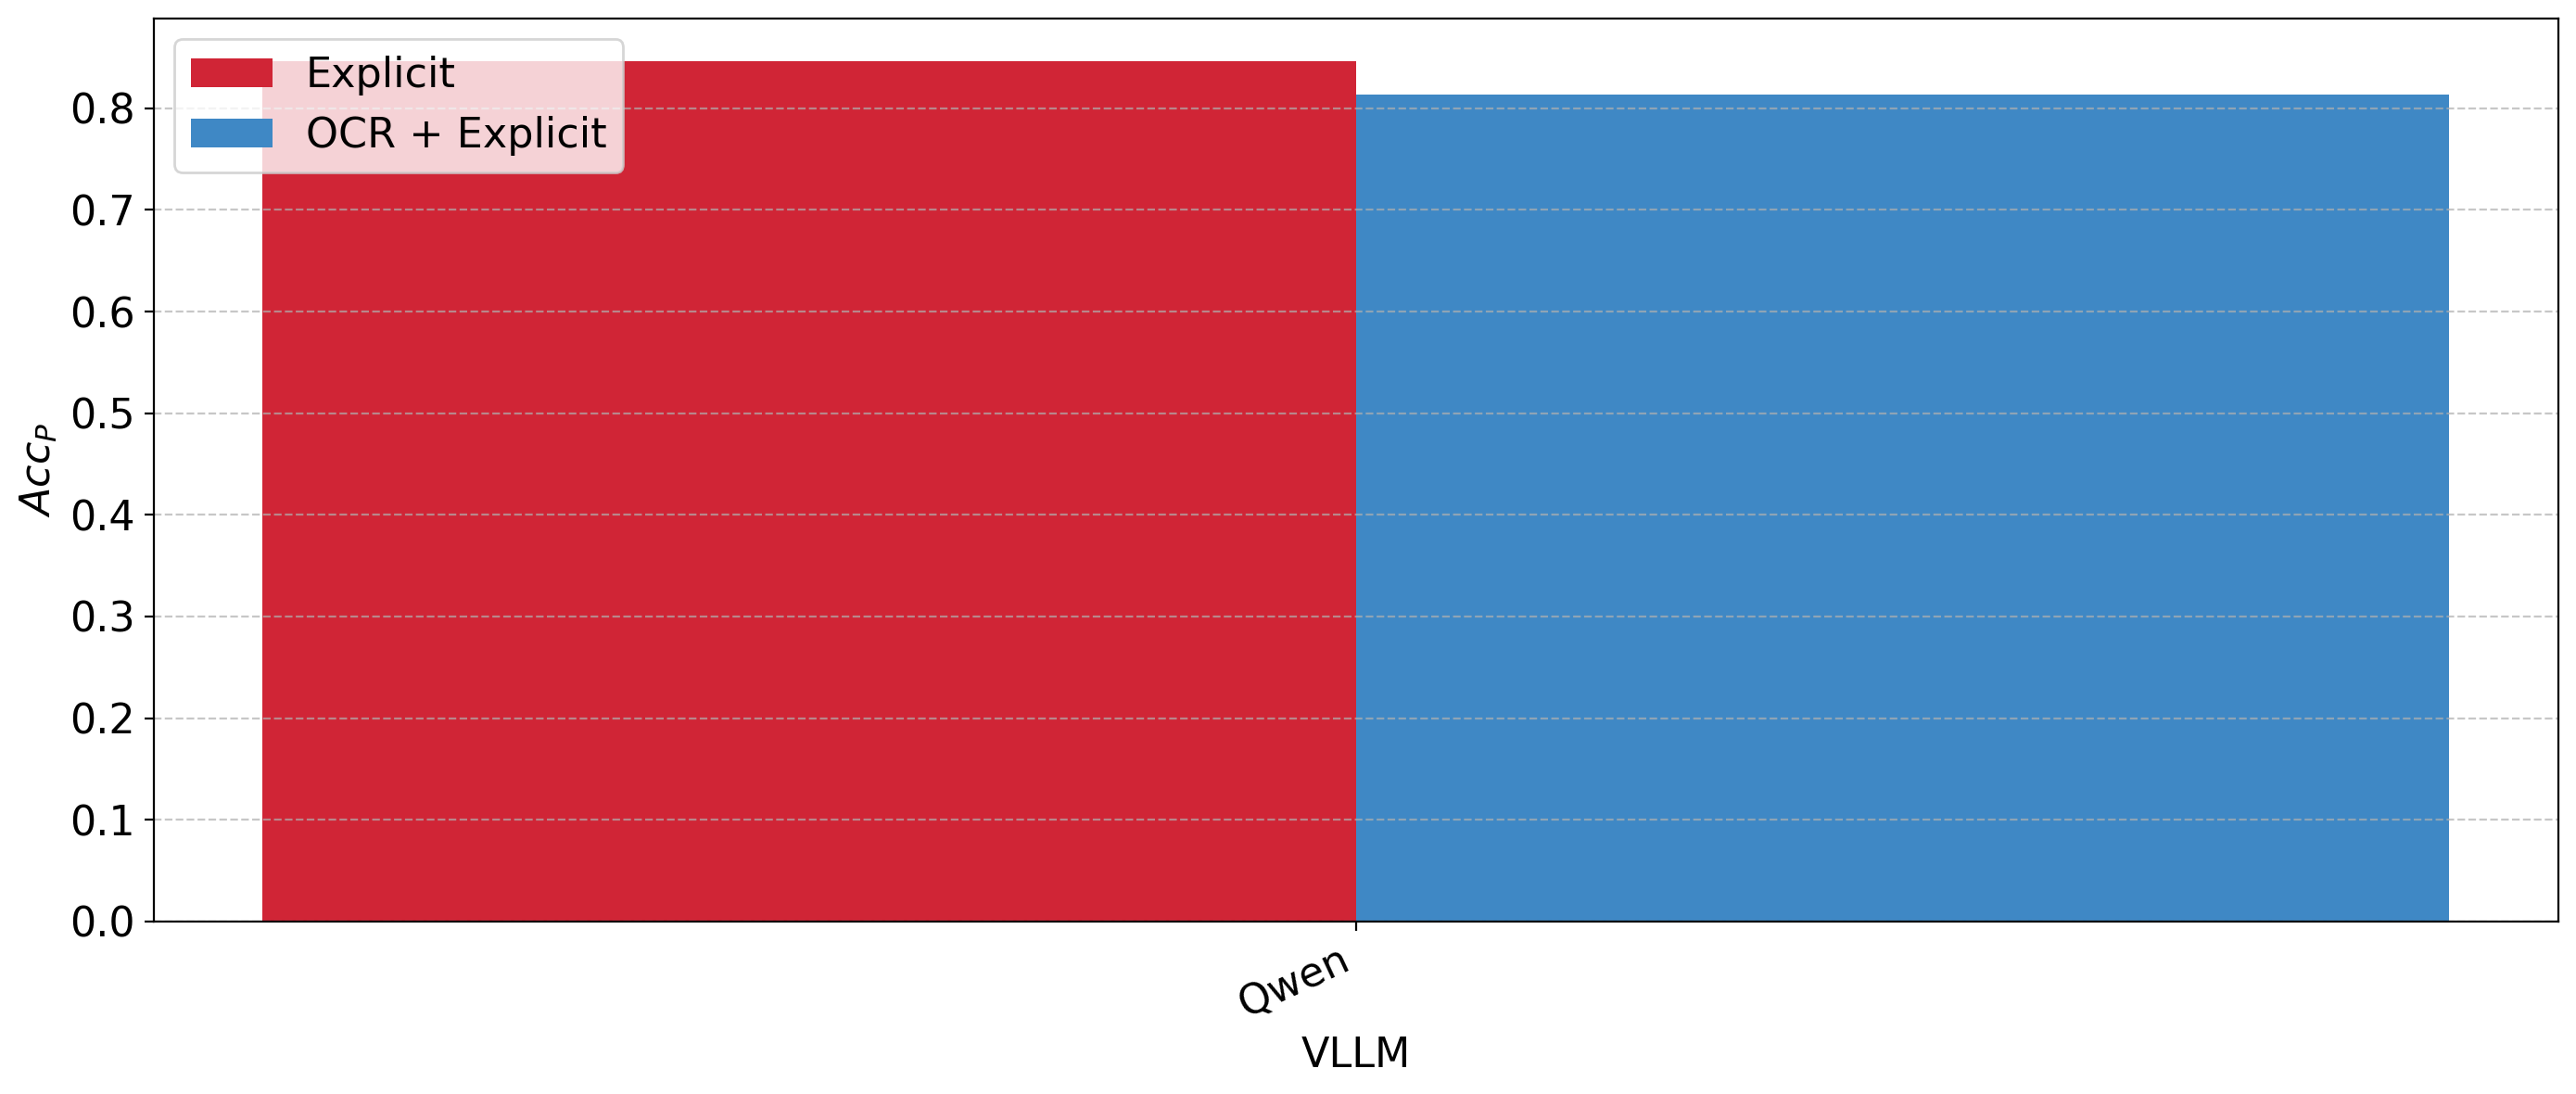

In [25]:
# AccP across inference conditions: unanswerability prompt (Explicit/None) × OCR injection
# Note: original had Molmo guard at i != 2, but Molmo is at index 1 in MODELS — fixed via MOLMO_IDX
folders = ["results_w1_OCR", "results_w1_OCR_fewshot_mixed_2"]
data = [load_metric(f, "UR", "UR") for f in folders]

bar_chart(
    data,
    group_labels=["Explicit", "OCR + Explicit", "None", "OCR"],
    colors=CONDITION_COLORS,
    ylabel="$Acc_P$",
    savepath=f"{UR_PLOT_DIR}/{DATASET}_UR_1parameter.pdf",
    # molmo_idx=MOLMO_IDX,
)

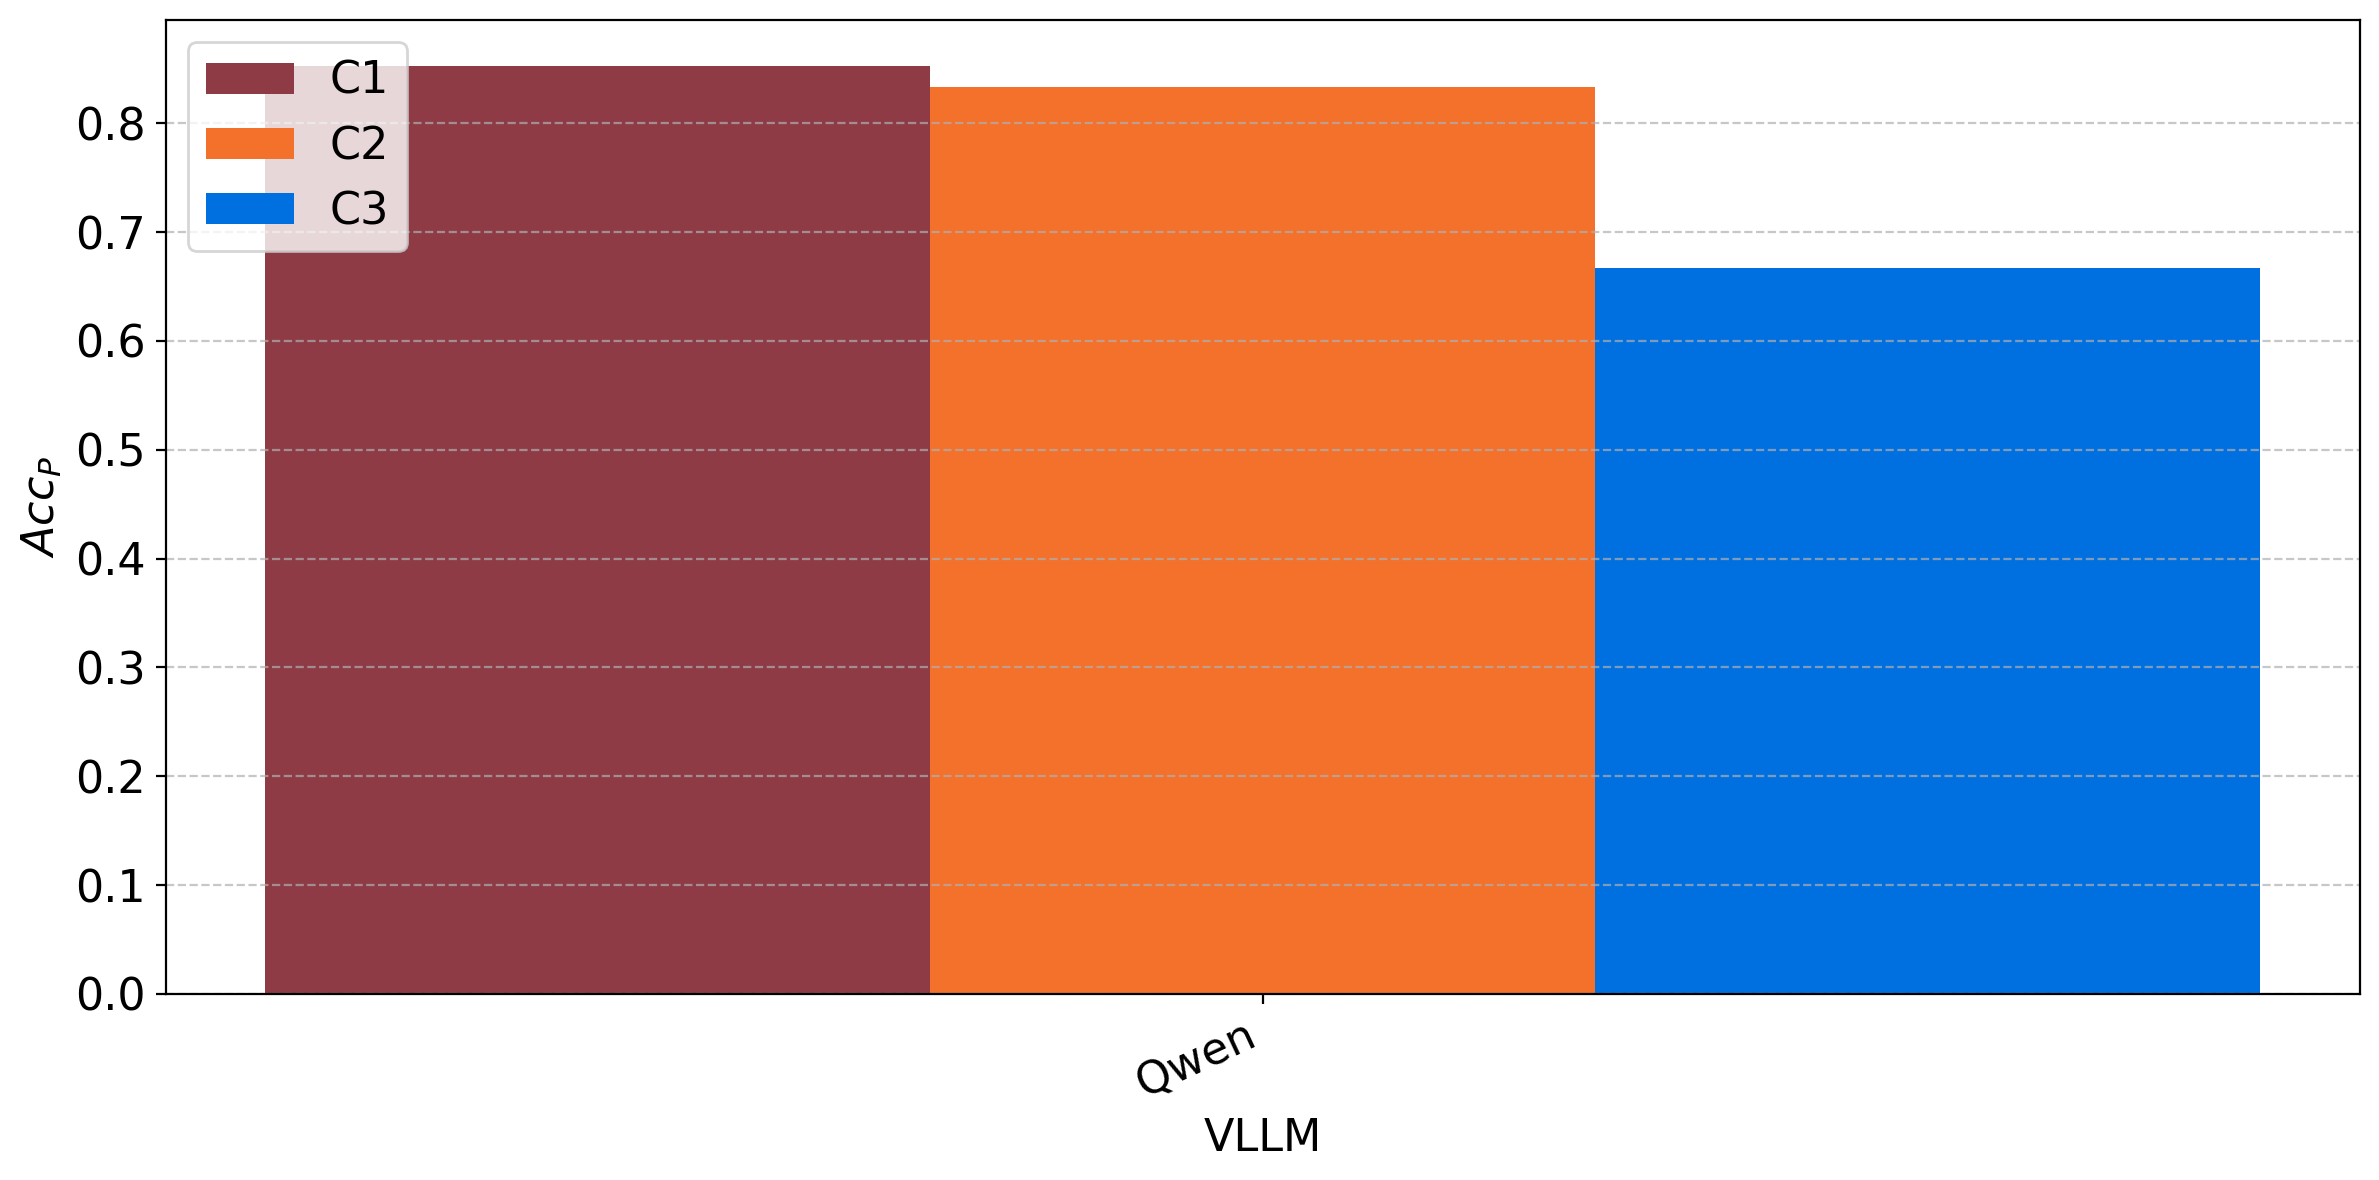

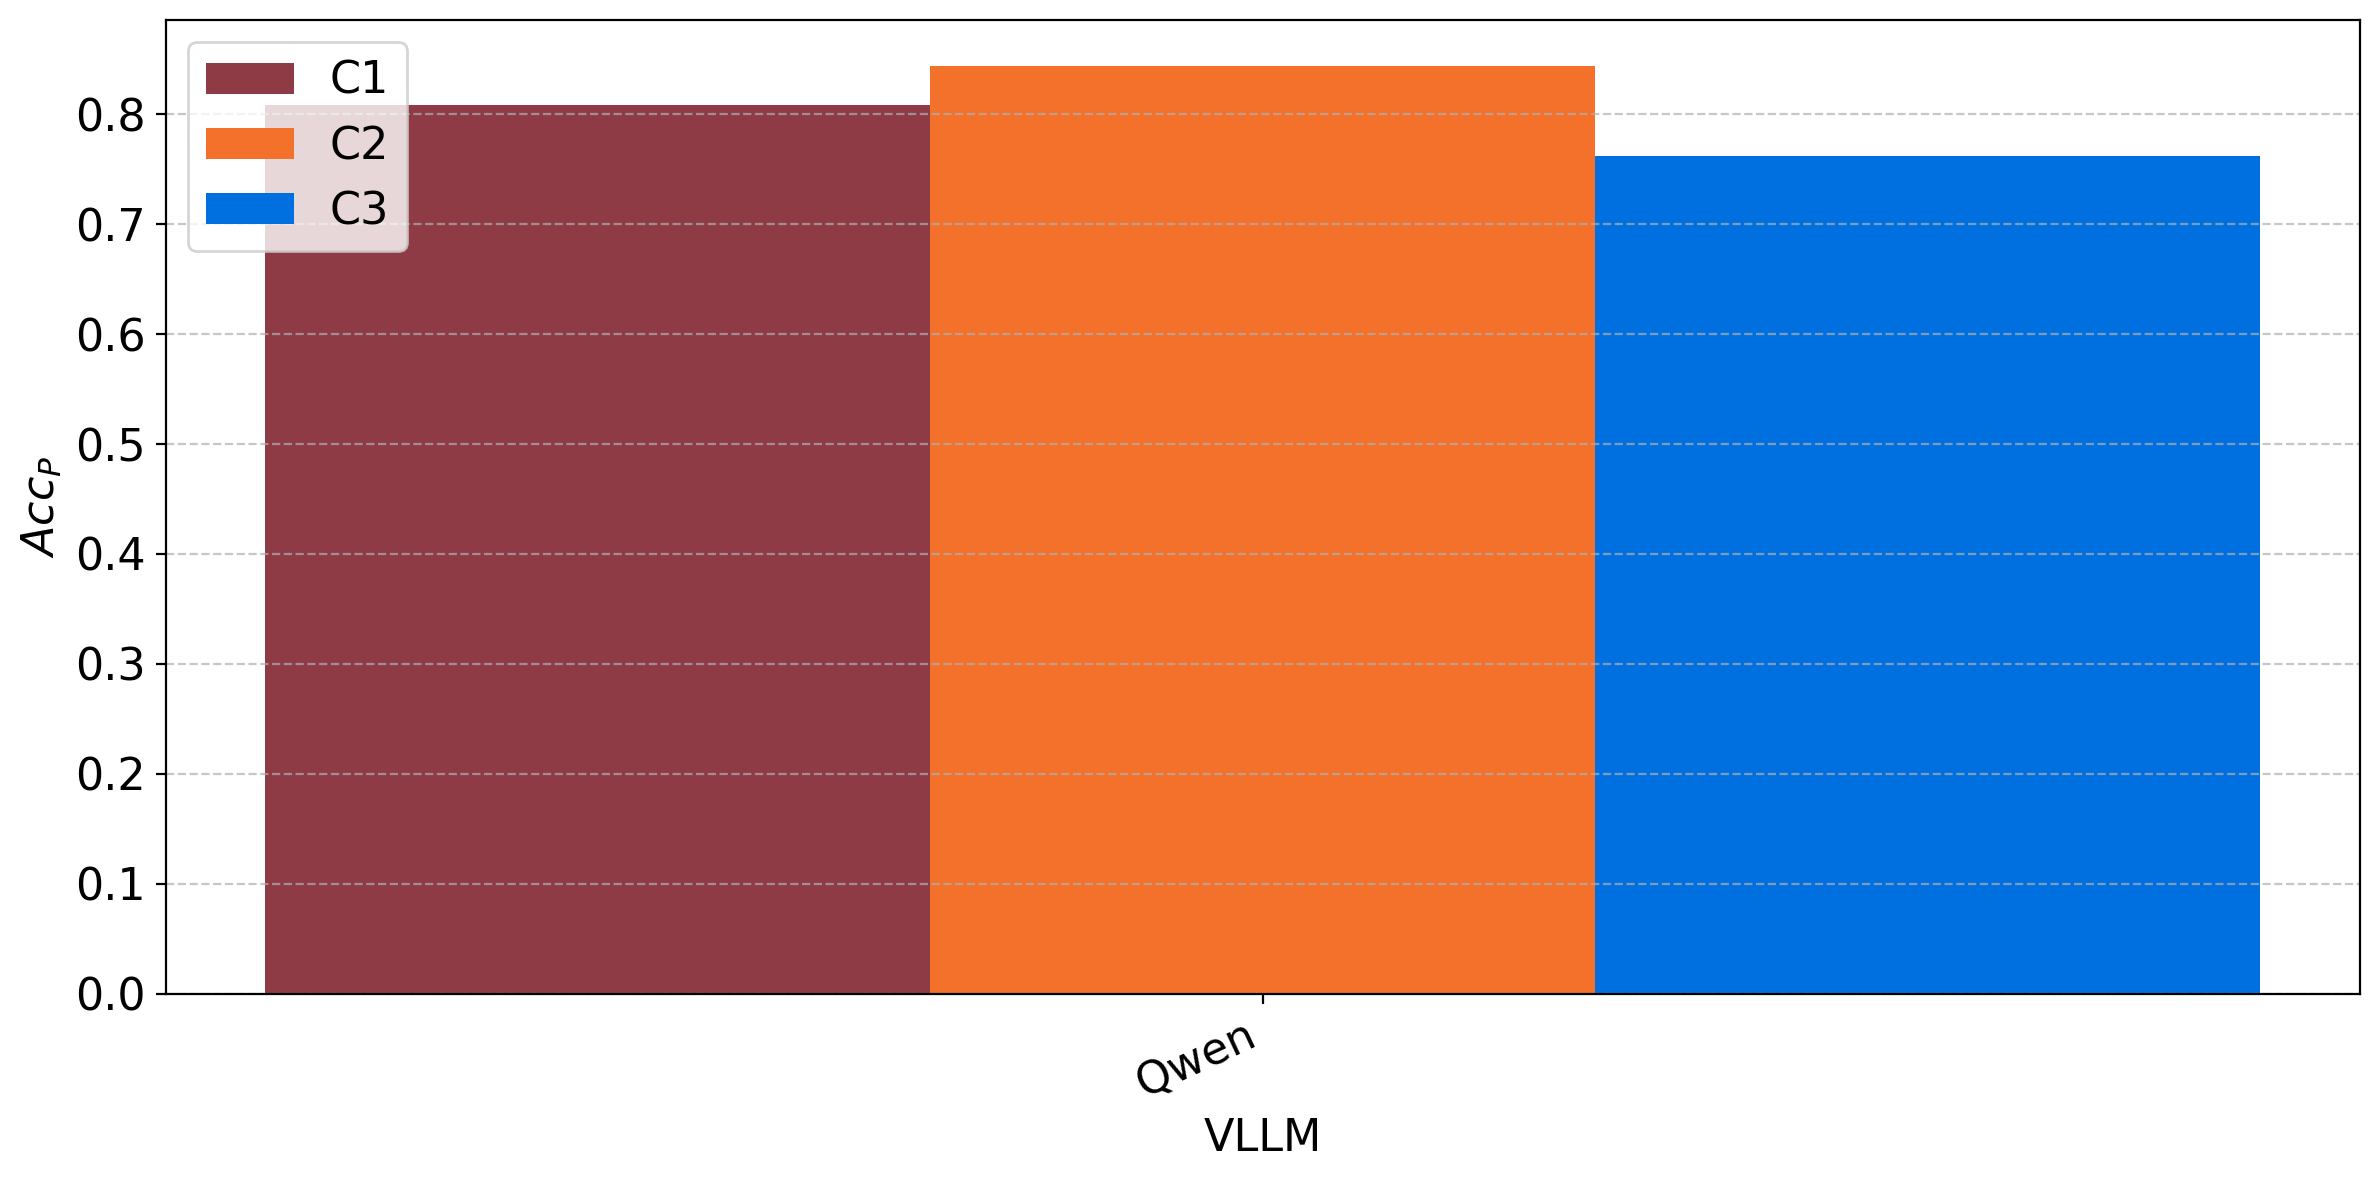

In [26]:
# AccP by corruption complexity (C1/C2/C3), one plot per inference condition
for folder in ["results_w1_OCR", "results_w1_OCR_fewshot_mixed_2"]:
    data = [load_metric(folder, "UR", key) for key in ["UR_C1", "UR_C2", "UR_C3"]]
    bar_chart(
        data,
        group_labels=["C1", "C2", "C3"],
        colors=COMPLEXITY_COLORS,
        ylabel="$Acc_P$",
        savepath=f"{UR_PLOT_DIR}/{DATASET}_{folder}_UR_complexity.pdf",
        figsize=(12, 6),
    )
